In [1]:
import os 
import pickle
import hashlib

import keras
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.losses import BinaryCrossentropy 
from sklearn.metrics import accuracy_score
import numpy as np

from qkeras.qlayers import QDense
from qkeras.quantizers import ternary

# os.environ['PATH'] = os.environ['XILINX_VIVADO'] + '/bin:' + os.environ['PATH'] # added: commented out for now
keras.utils.set_random_seed(32)

2026-02-05 10:38:38.996755: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-05 10:38:39.148347: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2026-02-05 10:38:39.148387: I tensorflow/compiler/xla/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.
2026-02-05 10:38:43.973937: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: libnvinfer.so.7: cannot open shared object file: No such file or directory
2026-

In [6]:
import os
import numpy as np

DATA_DIR = "./data"
X_TRAIN_FILE = "0528_X_train_0_770.npy"
Y_TRAIN_FILE = "0528_y_train_0_770.npy"

start_locations = [0, 100, 200, 300, 400, 500, 600]
window_sizes = [100, 200, 300, 400, 500, 600, 700, 770]

X_raw = np.load(os.path.join(DATA_DIR, X_TRAIN_FILE)).astype(np.float32)
y_raw = np.load(os.path.join(DATA_DIR, Y_TRAIN_FILE))

print("Raw X:", X_raw.shape, X_raw.dtype)
print("Raw y:", y_raw.shape, y_raw.dtype)

T = X_raw.shape[1]
print("Raw feature length (per example):", T)

def slice_window(X, start_location, window_size):
    end_window = start_location + window_size
    start = start_location * 2
    end = end_window * 2
    if start < 0 or end > X.shape[1]:
        return None
    return X[:, start:end]

for s in start_locations:
    for w in window_sizes:
        Xw = slice_window(X_raw, s, w)
        if Xw is None:
            print(f"start={s:4d}, win={w:4d} -> OUT OF RANGE (needs indices [{s*2}:{(s+w)*2}] within 0..{T})")
            continue

        print(
            f"start={s:4d}, win={w:4d} -> Xw={Xw.shape}, "
            f"min/max=({Xw.min():.3g},{Xw.max():.3g}), mean/std=({Xw.mean():.3g},{Xw.std():.3g})"
        )

        # Optional: check even/odd interleaving quickly
        even = Xw[:, 0::2]
        odd = Xw[:, 1::2]
        print(
            f"    even mean/std=({even.mean():.3g},{even.std():.3g}) | "
            f"odd mean/std=({odd.mean():.3g},{odd.std():.3g})"
        )

Raw X: (900000, 1540) float32
Raw y: (900000,) float64
Raw feature length (per example): 1540
start=   0, win= 100 -> Xw=(900000, 200), min/max=(-4.68e+03,4.72e+03), mean/std=(168,843)
    even mean/std=(228,843) | odd mean/std=(108,838)
start=   0, win= 200 -> Xw=(900000, 400), min/max=(-4.68e+03,4.72e+03), mean/std=(112,844)
    even mean/std=(150,844) | odd mean/std=(73.6,841)
start=   0, win= 300 -> Xw=(900000, 600), min/max=(-4.68e+03,4.72e+03), mean/std=(87.3,844)
    even mean/std=(118,844) | odd mean/std=(56.3,843)
start=   0, win= 400 -> Xw=(900000, 800), min/max=(-4.68e+03,4.72e+03), mean/std=(74.9,844)
    even mean/std=(102,844) | odd mean/std=(47.8,844)
start=   0, win= 500 -> Xw=(900000, 1000), min/max=(-4.88e+03,4.72e+03), mean/std=(67.6,844)
    even mean/std=(92.1,843) | odd mean/std=(43,844)
start=   0, win= 600 -> Xw=(900000, 1200), min/max=(-4.88e+03,4.72e+03), mean/std=(62.7,844)
    even mean/std=(85.3,843) | odd mean/std=(40.2,845)
start=   0, win= 700 -> Xw=(900

In [8]:
import os
import numpy as np

DATA_DIR = "./data"
X_TRAIN_FILE = "0528_X_train_0_770.npy"

start_locations = [0, 100, 200, 300, 400, 500, 600]
window_sizes = [100, 200, 300, 400, 500, 600, 700, 770]

sample_idx = 0  # pick a single example

X_raw = np.load(os.path.join(DATA_DIR, X_TRAIN_FILE)).astype(np.float32)
x0 = X_raw[sample_idx]  # shape: (T,)

T = x0.shape[0]
print("Single sample raw length:", T, "dtype:", x0.dtype)

def slice_window_1d(x, start_location, window_size):
    end_window = start_location + window_size
    start = start_location * 2
    end = end_window * 2
    if start < 0 or end > x.shape[0]:
        return None
    return x[start:end]

for s in start_locations:
    for w in window_sizes:
        xw = slice_window_1d(x0, s, w)
        if xw is None:
            print(f"start={s:4d}, win={w:4d} -> OUT OF RANGE (needs [{s*2}:{(s+w)*2}] within 0..{T})")
            continue

        even = xw[0::2]
        odd = xw[1::2]

        print(
            f"start={s:4d}, win={w:4d} -> len={len(xw):4d}, "
            f"min/max=({xw.min():.3g},{xw.max():.3g}), mean/std=({xw.mean():.3g},{xw.std():.3g})"
        )
        print(
            f"    even mean/std=({even.mean():.3g},{even.std():.3g}) | "
            f"odd mean/std=({odd.mean():.3g},{odd.std():.3g})"
        )

Single sample raw length: 1540 dtype: float32
start=   0, win= 100 -> len= 200, min/max=(-1.74e+03,2.2e+03), mean/std=(217,749)
    even mean/std=(228,796) | odd mean/std=(206,698)
start=   0, win= 200 -> len= 400, min/max=(-2.72e+03,2.2e+03), mean/std=(86.1,800)
    even mean/std=(90,851) | odd mean/std=(82.2,746)
start=   0, win= 300 -> len= 600, min/max=(-2.72e+03,2.2e+03), mean/std=(86.3,777)
    even mean/std=(69.9,821) | odd mean/std=(103,729)
start=   0, win= 400 -> len= 800, min/max=(-2.72e+03,2.41e+03), mean/std=(77.9,805)
    even mean/std=(37,834) | odd mean/std=(119,773)
start=   0, win= 500 -> len=1000, min/max=(-2.72e+03,2.41e+03), mean/std=(84.3,812)
    even mean/std=(24.1,828) | odd mean/std=(144,792)
start=   0, win= 600 -> len=1200, min/max=(-2.72e+03,2.41e+03), mean/std=(78.1,822)
    even mean/std=(20.4,831) | odd mean/std=(136,809)
start=   0, win= 700 -> len=1400, min/max=(-2.72e+03,2.41e+03), mean/std=(78.9,815)
    even mean/std=(21.8,821) | odd mean/std=(136,8

Picked idx0=0 (y=0), idx1=5000 (y=1)
Raw sample length: 1540


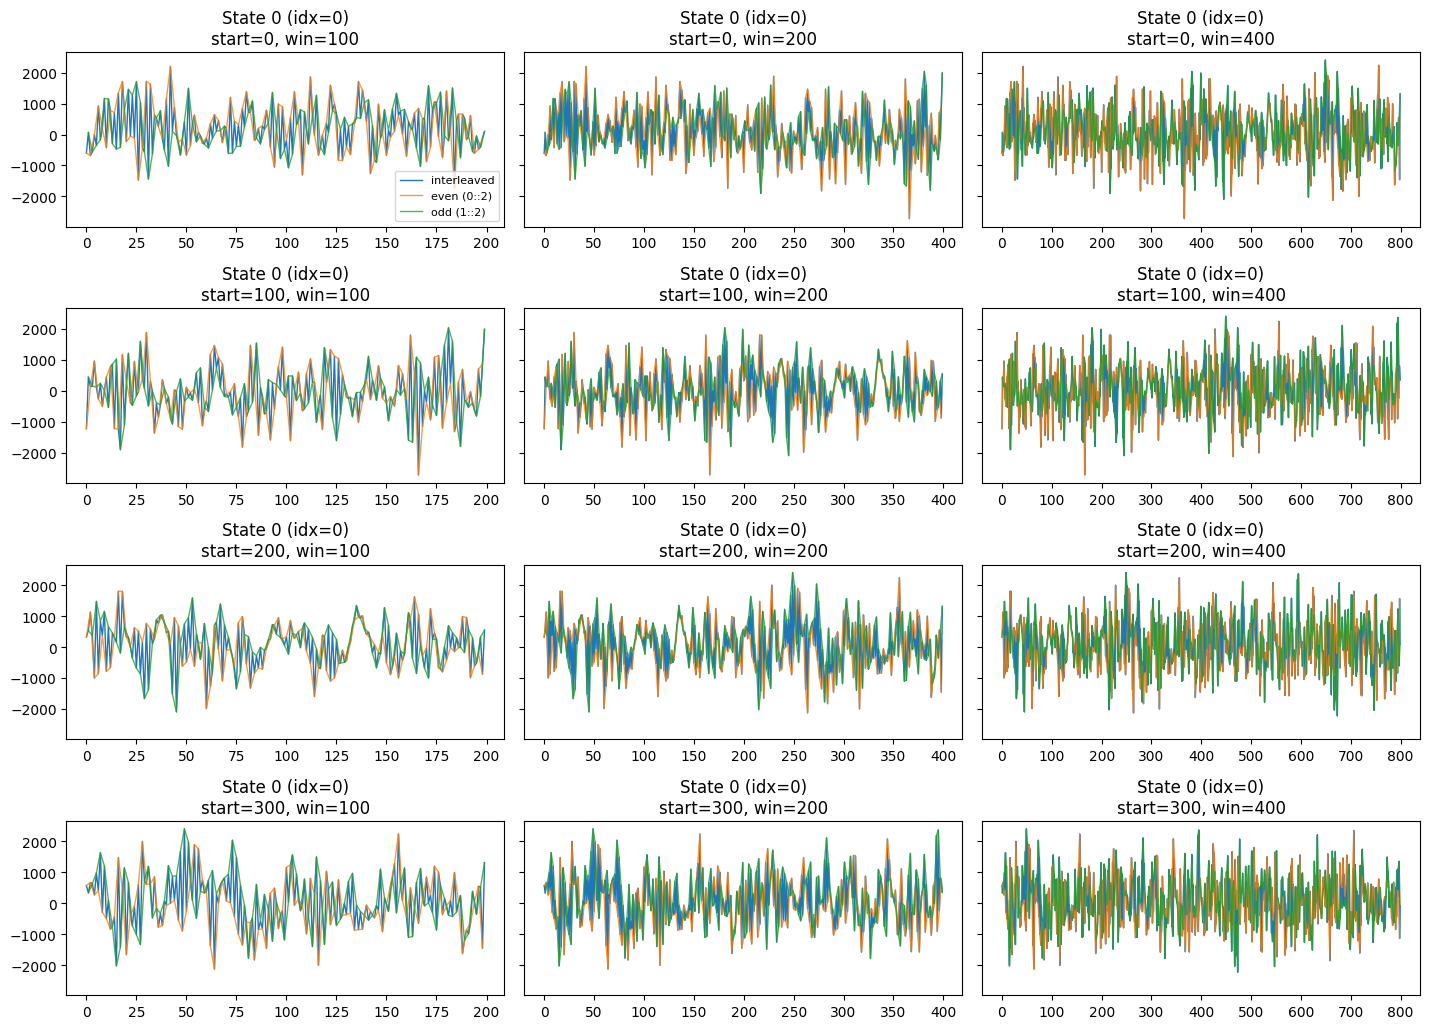

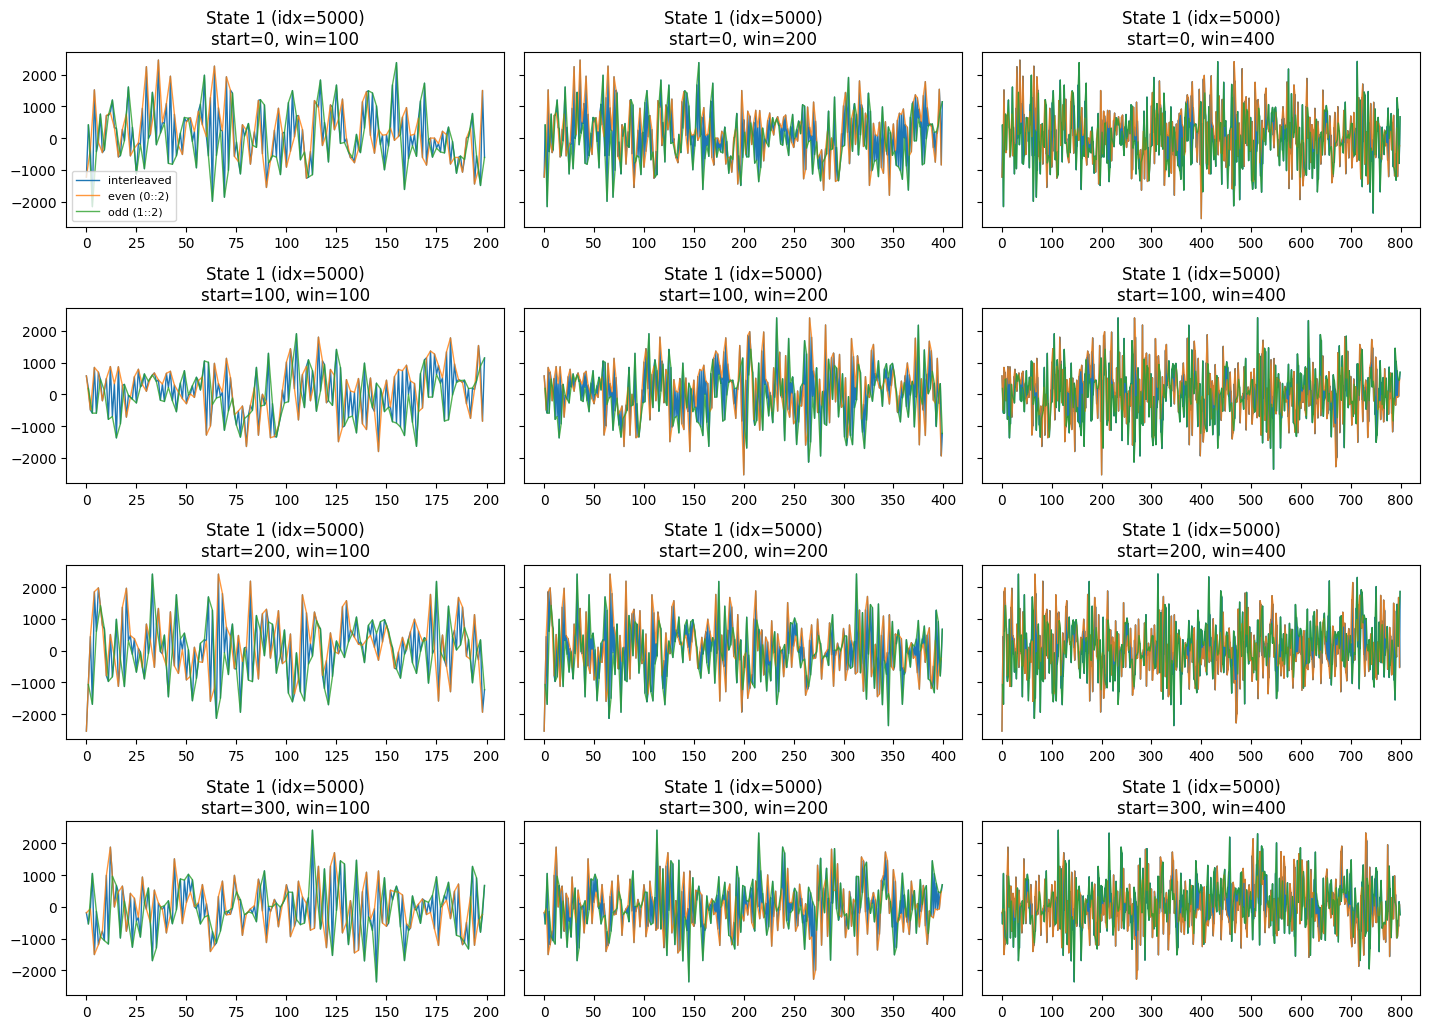

In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt

DATA_DIR = "../qubit/data"
X_TRAIN_FILE = "0528_X_train_0_770.npy"
Y_TRAIN_FILE = "0528_y_train_0_770.npy"

start_locations = [0, 100, 200, 300]
window_sizes = [100, 200, 400]

# Load raw data + labels
X_raw = np.load(os.path.join(DATA_DIR, X_TRAIN_FILE)).astype(np.float32)
y_raw = np.load(os.path.join(DATA_DIR, Y_TRAIN_FILE)).astype(np.int64)

# Pick one example from each class
idx0 = int(np.where(y_raw == 0)[0][0])
idx1 = int(np.where(y_raw == 1)[0][0])

x_state0 = X_raw[idx0]
x_state1 = X_raw[idx1]

print(f"Picked idx0={idx0} (y=0), idx1={idx1} (y=1)")
print("Raw sample length:", x_state0.shape[0])

def slice_window_1d(x, start_location, window_size):
    start = start_location * 2
    end = (start_location + window_size) * 2
    if start < 0 or end > x.shape[0]:
        return None
    return x[start:end]

def plot_grid_for_sample(x, label_text):
    n_rows = len(start_locations)
    n_cols = len(window_sizes)
    fig, axes = plt.subplots(
        n_rows, n_cols, figsize=(4.8 * n_cols, 2.6 * n_rows), sharey=True
    )

    if n_rows == 1 and n_cols == 1:
        axes = np.array([[axes]])
    elif n_rows == 1:
        axes = axes.reshape(1, -1)
    elif n_cols == 1:
        axes = axes.reshape(-1, 1)

    for i, s in enumerate(start_locations):
        for j, w in enumerate(window_sizes):
            ax = axes[i, j]
            xw = slice_window_1d(x, s, w)
            ax.set_title(f"{label_text}\nstart={s}, win={w}")

            if xw is None:
                ax.text(0.5, 0.5, "OUT OF RANGE", ha="center", va="center", transform=ax.transAxes)
                ax.set_axis_off()
                continue

            # interleaved
            ax.plot(xw, linewidth=1.0, label="interleaved")

            # even/odd overlay (interpretable as 2 interleaved channels)
            even = xw[0::2]
            odd = xw[1::2]
            ax.plot(np.arange(0, len(xw), 2), even, linewidth=1.0, alpha=0.8, label="even (0::2)")
            ax.plot(np.arange(1, len(xw), 2), odd, linewidth=1.0, alpha=0.8, label="odd (1::2)")

            if i == 0 and j == 0:
                ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()

# Plot one grid for state 0 and one for state 1
plot_grid_for_sample(x_state0, f"State 0 (idx={idx0})")
plot_grid_for_sample(x_state1, f"State 1 (idx={idx1})")